<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 01: Simple comparative experiments

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 2.
Problem numbers follow the 8th edition.

## Learning goals

* Compare two treatments with the two-sample $t$-test (pooled and Welch) and interpret the $p$-value and the confidence interval.
* Test the equality of two variances with the $F$-test.
* Check the normality assumption (kernel density estimate, normal probability plot, Shapiro-Wilk test).
* Compute the power of a test and the sample size needed to reach a given power.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, shapiro
from statsmodels.stats.power import TTestIndPower

## Example from the lecture: Portland cement mortar

Lecture 1 compared the tension bond strength of a modified and an unmodified mortar formulation
(Montgomery, Example 2.1). We repeat the analysis in Python: $F$-test for the variances, two-sample $t$-tests,
confidence intervals, normality checks, and the power of the test.

In [2]:
# Data arrays
y1 = np.array([16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57])  # Modified Mortar
y2 = np.array([16.62,16.75,17.37,17.12,16.98,16.87,17.34,17.02,17.08,17.27])  # Unmodified Mortar

# Sample variances
s1_squared = np.var(y1, ddof=1)
s2_squared = np.var(y2, ddof=1)

# Degrees of freedom
dfn = len(y1) - 1  # Degrees of freedom numerator
dfd = len(y2) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

print('F-statistic:', F)
print('Degrees of freedom:', dfn, 'and', dfd)
print('p-value:', p_value)

F-statistic: 1.6292573577265188
Degrees of freedom: 9 and 9
p-value: 0.47846033941944155


In [3]:
# 1. Two-sample t-test assuming equal variances (pooled; var.equal = TRUE in R)
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Calculate confidence interval for equal variance
n1, n2 = len(y1), len(y2)
mean_diff = np.mean(y1) - np.mean(y2)
pooled_std = np.sqrt(((n1 - 1) * np.var(y1, ddof=1) + (n2 - 1) * np.var(y2, ddof=1)) / (n1 + n2 - 2))
se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)

# 2. Welch's t-test (var.equal = FALSE in R)
t_stat_unequal_var, p_value_unequal_var = stats.ttest_ind(y1, y2, equal_var=False)
df_unequal_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))

# Calculate confidence interval for unequal variance
se_unequal = np.sqrt(np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)
conf_interval_unequal_var = stats.t.interval(0.95, df=df_unequal_var, loc=mean_diff, scale=se_unequal)

# Results for t-test assuming equal variances
print("Two-Sample T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat_equal_var}")
print(f"p-value: {p_value_equal_var}")
print(f"95% confidence interval: {conf_interval_equal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")
print()

# Results for Welch's t-test (unequal variances)
print("Welch's Two-Sample T-Test (Assuming Unequal Variances)")
print(f"t-statistic: {t_stat_unequal_var}")
print(f"p-value: {p_value_unequal_var}")
print(f"Degrees of freedom: {df_unequal_var}")
print(f"95% confidence interval: {conf_interval_unequal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")


Two-Sample T-Test Assuming Equal Variances
t-statistic: -2.1868757949582633
p-value: 0.042196715924889903
95% confidence interval: (np.float64(-0.5450733877678522), np.float64(-0.010926612232152355))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005

Welch's Two-Sample T-Test (Assuming Unequal Variances)
t-statistic: -2.1868757949582633
p-value: 0.042998380088903
Degrees of freedom: 17.02484516235282
95% confidence interval: (np.float64(-0.5461741394750395), np.float64(-0.00982586052496498))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005


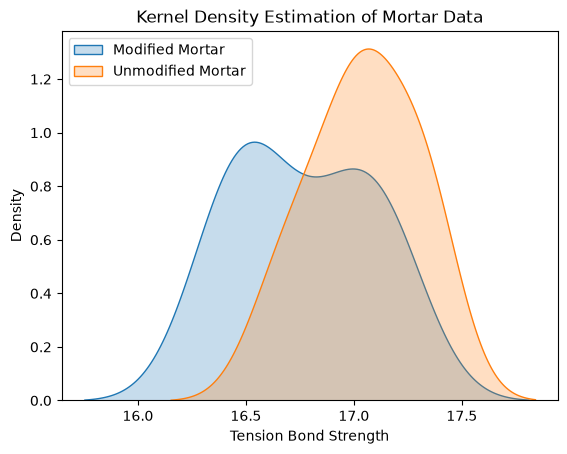

In [4]:
# Kernel Density Plot
sns.kdeplot(y1, fill=True, label='Modified Mortar')
sns.kdeplot(y2, fill=True, label='Unmodified Mortar')
plt.title('Kernel Density Estimation of Mortar Data')
plt.xlabel('Tension Bond Strength')
plt.legend()
plt.show()

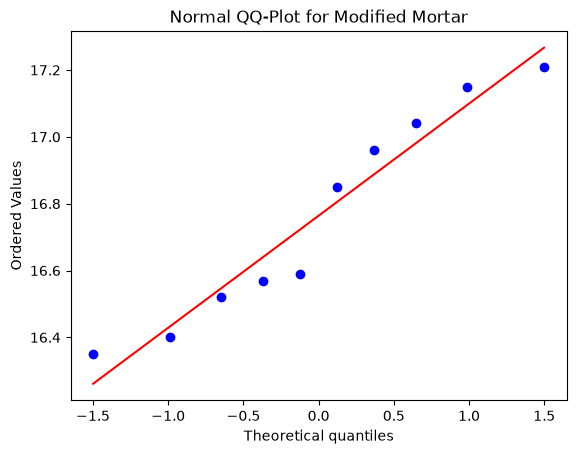

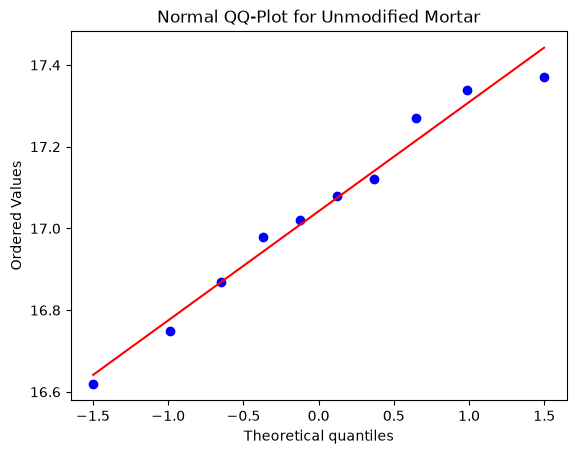

In [5]:
# QQ-Plot for y1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Modified Mortar')
plt.show()

# QQ-Plot for y2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Unmodified Mortar')
plt.show()

In [6]:
# Shapiro-Wilk test for y1
statistic_y1, p_value_y1 = shapiro(y1)
print(f'Shapiro-Wilk Test for y1: Statistic={statistic_y1}, p-value={p_value_y1}')

# Shapiro-Wilk test for y2
statistic_y2, p_value_y2 = shapiro(y2)
print(f'Shapiro-Wilk Test for y2: Statistic={statistic_y2}, p-value={p_value_y2}')

Shapiro-Wilk Test for y1: Statistic=0.9186332804164983, p-value=0.34569686488904733
Shapiro-Wilk Test for y2: Statistic=0.9626192874099935, p-value=0.815277309128182


In [7]:
# Parameters
effect_size = (np.mean(y1) - np.mean(y2)) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.95

# Create an instance of the power analysis class
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group: {np.ceil(sample_size)}')

# Calculate power of the test with n=10
actual_power = analysis.power(effect_size=effect_size, nobs1=10, alpha=alpha, alternative='two-sided')
print(f'Power of the test with n=10 per group: {actual_power}')

Required sample size per group: 29.0
Power of the test with n=10 per group: 0.543644227812624


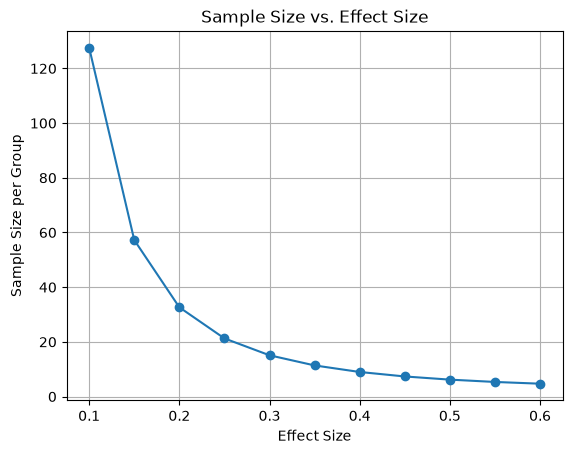

In [8]:
# Parameters
alpha = 0.05
power = 0.80
sd = 0.284  # Standard deviation
effect_sizes = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])

# Calculate sample sizes
analysis = TTestIndPower()
sample_sizes = []
for delta in effect_sizes:
    effect_size = delta / sd
    n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    sample_sizes.append(n)

# Plotting
plt.plot(effect_sizes, sample_sizes, marker='o')
plt.xlabel('Effect Size')
plt.ylabel('Sample Size per Group')
plt.title('Sample Size vs. Effect Size')
plt.grid(True)
plt.show()


## Assignment

* Run the notebook above and get familiar with Python.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition). Start in class and finish at home.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex01_HW_<Surname>.ipynb` (see `HW/README.md`).
  **Deadline: Sunday 4 October 2026** (the next lecture is on 5 October; 28 September is a public holiday).

### Exercise 2.20

The shelf life of a carbonated beverage is of interest. Ten bottles are randomly selected and tested,
and the following results (in days) are obtained:

| | | | | |
|---|---|---|---|---|
| 108 | 124 | 124 | 106 | 115 |
| 138 | 163 | 159 | 134 | 139 |

* We would like to demonstrate that the mean shelf life exceeds 120 days. Set up appropriate hypotheses for investigating this claim.
* Test these hypotheses using significance level $\alpha = 0.01$. Find the P-value for the test. What are your conclusions?
* Construct a 99 percent confidence interval on the mean shelf life.
* Can shelf life be adequately described or modeled by a normal distribution? What effect would a violation of this assumption have on the test procedure you used in solving the previous questions?

In [9]:
# Read the data from the URL
url_20 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_20.csv"
df20 = pd.read_csv(url_20, sep=";")

# Display the first few rows of the dataframe
df20.head()


,Days
0,108
1,124
2,124
3,106
4,115


**Solution:**

In [13]:
# Hypotheses: H0: mu = 120  vs  H1: mu > 120  (one-sided), alpha = 0.01
y20 = df20["Days"].to_numpy()
n20 = len(y20)
alpha = 0.01

mean20 = np.mean(y20)
s20 = np.std(y20, ddof=1)
se20 = s20 / np.sqrt(n20)

# One-sample t-test against mu0 = 120, upper-tailed
t_stat20, p_value20 = stats.ttest_1samp(y20, popmean=120, alternative="greater")
t_crit20 = t.ppf(1 - alpha, df=n20 - 1)

print(f"n = {n20}, mean = {mean20:.3f}, s = {s20:.3f}, se = {se20:.3f}")
print(f"t-statistic: {t_stat20:.4f}  (critical value t_0.99,{n20-1} = {t_crit20:.4f})")
print(f"one-sided p-value: {p_value20:.4f}")
print("Reject H0" if p_value20 < alpha else "Do not reject H0", f"at alpha = {alpha}")


n = 10, mean = 131.000, s = 19.545, se = 6.181
t-statistic: 1.7798  (critical value t_0.99,9 = 2.8214)
one-sided p-value: 0.0544
Do not reject H0 at alpha = 0.01


In [14]:
# 99% two-sided confidence interval on the mean shelf life
ci20 = t.interval(0.99, df=n20 - 1, loc=mean20, scale=se20)
print(f"99% CI for mu: ({ci20[0]:.3f}, {ci20[1]:.3f})")
print(f"120 days {'lies inside' if ci20[0] <= 120 <= ci20[1] else 'lies outside'} the interval")

# One-sided lower bound, the interval matching the upper-tailed test above
lower_bound20 = mean20 - t_crit20 * se20
print(f"99% lower confidence bound: mu > {lower_bound20:.3f}")


99% CI for mu: (110.914, 151.086)
120 days lies inside the interval
99% lower confidence bound: mu > 113.562


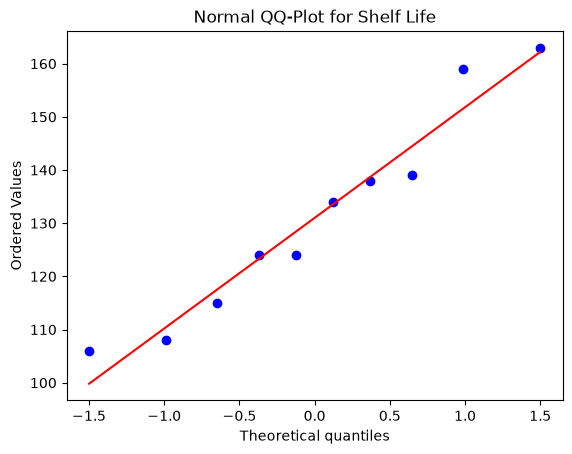

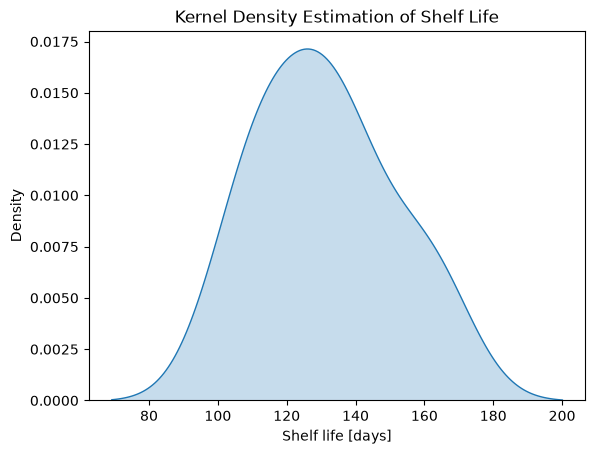

Shapiro-Wilk test: statistic = 0.9365, p-value = 0.5152


In [ ]:
# Normality check: QQ-plot and Shapiro-Wilk test
plt.figure()
stats.probplot(y20, dist="norm", plot=plt)
plt.title("Normal QQ-Plot for Shelf Life")
plt.show()

sns.kdeplot(y20, fill=True)
plt.title("Kernel Density Estimation of Shelf Life")
plt.xlabel("Shelf life [days]")
plt.show()

stat_sw20, p_sw20 = shapiro(y20)
print(f"Shapiro-Wilk test: statistic = {stat_sw20:.4f}, p-value = {p_sw20:.4f}")



since Shapiro-Wilk test:
H0 - data come from normal distribution
H1 - they dont

-> large p value - we don't reject the hypothesis that data comes from random distribution.

### Exercise 2.21

In semiconductor manufacturing, wet chemical etching is often used to remove silicon from the backs of wafers prior to metallization. The **etch rate** is an important characteristic of this process. Two different etching solutions are being evaluated. Eight randomly selected wafers have been etched in each solution and the observed etch rates (in mils/min) are shown below:

| Solution 1 | Solution 2 |
|------------|------------|
|  9.9       | 10.2       |
|  9.4       | 10.0       |
| 10.0       | 10.7       |
| 10.3       | 10.5       |
| 10.6       | 10.6       |
| 10.3       | 10.2       |
|  9.3       | 10.4       |
|  9.8       | 10.3       |

**(a)** Do the data indicate that the claim that both solutions have the same mean etch rate is valid? Use α = 0.05 and assume equal variances.  

**(b)** Find a 95% confidence interval on the difference in mean etch rates.  

**(c)** Use normal probability plots to investigate the adequacy of the assumptions of normality and equal variances.  

**(d)** Compute the power of the test in part (a). Assume that the true difference in means and the common variance equal the estimates obtained from the data. How many observations per group would be required to achieve power greater than 0.9 to detect a difference of Δ = 0.3 at significance level α = 0.05?


In [10]:
# Read the data from the URL
url_21 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_21.csv"
df21 = pd.read_csv(url_21, sep=";")

# Display the first few rows of the dataframe
df21.head()

,Solution1,Solution2
0,9.9,10.2
1,9.4,10.0
2,10.0,10.7
3,10.3,10.5
4,10.6,10.6


**Solution:**

In [16]:
# (a) Do both solutions have the same mean etch rate? alpha = 0.05, equal variances assumed
s1_21 = df21["Solution1"].to_numpy()
s2_21 = df21["Solution2"].to_numpy()
n1_21, n2_21 = len(s1_21), len(s2_21)
alpha21 = 0.05

var1_21 = np.var(s1_21, ddof=1)
var2_21 = np.var(s2_21, ddof=1)

# F-test for equality of variances, H0: sigma1^2 = sigma2^2 (supports the pooled t-test below)
F_21 = var1_21 / var2_21
p_F_21 = 2 * min(f.cdf(F_21, n1_21 - 1, n2_21 - 1), 1 - f.cdf(F_21, n1_21 - 1, n2_21 - 1))
print(f"s1^2 = {var1_21:.4f}, s2^2 = {var2_21:.4f}")
print(f"F = {F_21:.4f} on ({n1_21-1}, {n2_21-1}) df, two-sided p-value = {p_F_21:.4f}")
print("Equal variances rejected" if p_F_21 < alpha21 else "No evidence against equal variances")

# Pooled two-sample t-test, H0: mu1 = mu2 vs H1: mu1 != mu2
t_21, p_21 = stats.ttest_ind(s1_21, s2_21, equal_var=True)
df_21 = n1_21 + n2_21 - 2
t_crit21 = t.ppf(1 - alpha21 / 2, df=df_21)

print(f"\nmean1 = {s1_21.mean():.4f}, mean2 = {s2_21.mean():.4f}, difference = {s1_21.mean() - s2_21.mean():.4f}")
print(f"t-statistic: {t_21:.4f} on {df_21} df  (critical value +/-{t_crit21:.4f})")
print(f"two-sided p-value: {p_21:.4f}")
print("Reject H0" if p_21 < alpha21 else "Do not reject H0", f"at alpha = {alpha21}")


s1^2 = 0.2029, s2^2 = 0.0541
F = 3.7492 on (7, 7) df, two-sided p-value = 0.1024
No evidence against equal variances

mean1 = 9.9500, mean2 = 10.3625, difference = -0.4125
t-statistic: -2.3016 on 14 df  (critical value +/-2.1448)
two-sided p-value: 0.0372
Reject H0 at alpha = 0.05


In [17]:
# (b) 95% confidence interval on the difference in mean etch rates
sp_21 = np.sqrt(((n1_21 - 1) * var1_21 + (n2_21 - 1) * var2_21) / df_21)
se_21 = sp_21 * np.sqrt(1 / n1_21 + 1 / n2_21)
diff_21 = s1_21.mean() - s2_21.mean()

ci_21 = t.interval(0.95, df=df_21, loc=diff_21, scale=se_21)
print(f"pooled sd = {sp_21:.4f}, standard error of the difference = {se_21:.4f}")
print(f"95% CI for mu1 - mu2: ({ci_21[0]:.4f}, {ci_21[1]:.4f})")
print(f"0 {'lies inside' if ci_21[0] <= 0 <= ci_21[1] else 'lies outside'} the interval"
      f" -> {'consistent with equal means' if ci_21[0] <= 0 <= ci_21[1] else 'means differ'}")


pooled sd = 0.3584, standard error of the difference = 0.1792
95% CI for mu1 - mu2: (-0.7969, -0.0281)
0 lies outside the interval -> means differ


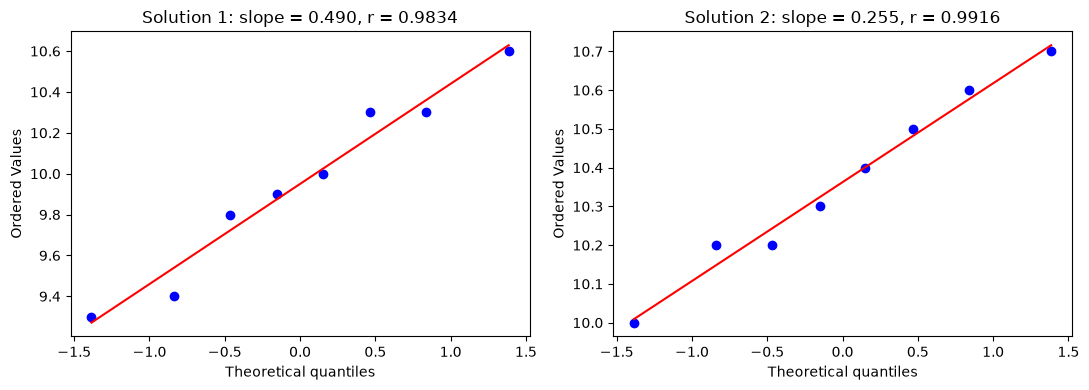

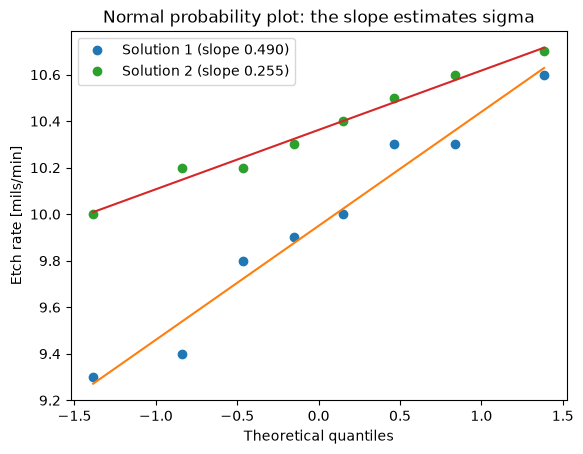

Shapiro-Wilk Solution 1: statistic = 0.9549, p-value = 0.7603
Shapiro-Wilk Solution 2: statistic = 0.9768, p-value = 0.9454

sample sd: Solution 1 = 0.4504, Solution 2 = 0.2326


In [18]:
# (c) Normal probability plots: normality, and equal variances via the slopes
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y, name in zip(axes, [s1_21, s2_21], ["Solution 1", "Solution 2"]):
    (osm, osr), (slope, intercept, r) = stats.probplot(y, dist="norm", plot=ax)
    ax.set_title(f"{name}: slope = {slope:.3f}, r = {r:.4f}")
plt.tight_layout()
plt.show()

# Both samples on the same axes: roughly parallel lines => comparable variances
plt.figure()
for y, name in zip([s1_21, s2_21], ["Solution 1", "Solution 2"]):
    (osm, osr), (slope, intercept, r) = stats.probplot(y, dist="norm")
    plt.plot(osm, osr, "o", label=f"{name} (slope {slope:.3f})")
    plt.plot(osm, intercept + slope * osm, "-")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Etch rate [mils/min]")
plt.title("Normal probability plot: the slope estimates sigma")
plt.legend()
plt.show()

# Formal companion to the plots
for y, name in zip([s1_21, s2_21], ["Solution 1", "Solution 2"]):
    stat_sw, p_sw = shapiro(y)
    print(f"Shapiro-Wilk {name}: statistic = {stat_sw:.4f}, p-value = {p_sw:.4f}")
print(f"\nsample sd: Solution 1 = {np.sqrt(var1_21):.4f}, Solution 2 = {np.sqrt(var2_21):.4f}")


In [ ]:
# (c) continued: how much does the equal-variance assumption matter?
# The F-test acceptance region at alpha = 0.05 is very wide with (7, 7) df,
# so "not rejected" is weak evidence that the variances agree.
F_lower = f.ppf(alpha21 / 2, n1_21 - 1, n2_21 - 1)
F_upper = f.ppf(1 - alpha21 / 2, n1_21 - 1, n2_21 - 1)
print(f"sd1 = {np.sqrt(var1_21):.4f}, sd2 = {np.sqrt(var2_21):.4f}, ratio = {np.sqrt(var1_21/var2_21):.3f}")
print(f"variance ratio F = {F_21:.4f}, acceptance region = ({F_lower:.4f}, {F_upper:.4f})")

# Welch's test: same comparison without assuming equal variances
t_welch, p_welch = stats.ttest_ind(s1_21, s2_21, equal_var=False)
df_welch = ((var1_21 / n1_21 + var2_21 / n2_21) ** 2) / \
           ((var1_21 / n1_21) ** 2 / (n1_21 - 1) + (var2_21 / n2_21) ** 2 / (n2_21 - 1))
se_welch = np.sqrt(var1_21 / n1_21 + var2_21 / n2_21)
ci_welch = t.interval(0.95, df=df_welch, loc=diff_21, scale=se_welch)

print(f"\npooled: t = {t_21:.4f}, df = {df_21}, p = {p_21:.4f}, 95% CI = ({ci_21[0]:.4f}, {ci_21[1]:.4f})")
print(f"Welch : t = {t_welch:.4f}, df = {df_welch:.3f}, p = {p_welch:.4f}, 95% CI = ({ci_welch[0]:.4f}, {ci_welch[1]:.4f})")


The two $t$-statistics are identical because $n_1 = n_2$; with equal sample sizes the pooled and
Welch statistics coincide algebraically and only the degrees of freedom differ ($14$ against $10.49$),
which widens the confidence interval slightly.

Both tests reject $H_0$ at $\alpha = 0.05$, so the conclusion of parts (a) and (b) does not rest on the
equal-variance assumption.


In [19]:
# (d) Power of the test in (a), and the sample size needed to detect delta = 0.3
analysis21 = TTestIndPower()

# Power at the observed difference, with n = 8 per group
effect_observed = diff_21 / sp_21
power_21 = analysis21.power(effect_size=effect_observed, nobs1=n1_21, alpha=alpha21, alternative="two-sided")
print(f"observed difference = {diff_21:.4f}, pooled sd = {sp_21:.4f}")
print(f"effect size (Cohen's d) = {effect_observed:.4f}")
print(f"power with n = {n1_21} per group: {power_21:.4f}")

# Sample size to reach power > 0.9 for a true difference of delta = 0.3
delta21 = 0.3
effect_delta = delta21 / sp_21
n_needed = analysis21.solve_power(effect_size=effect_delta, alpha=alpha21, power=0.9, alternative="two-sided")
print(f"\nto detect delta = {delta21} (effect size {effect_delta:.4f}) with power 0.9:")
print(f"required sample size per group: {np.ceil(n_needed):.0f}  (exact {n_needed:.2f})")


observed difference = -0.4125, pooled sd = 0.3584
effect size (Cohen's d) = -1.1508
power with n = 8 per group: 0.5724

to detect delta = 0.3 (effect size 0.8370) with power 0.9:
required sample size per group: 31  (exact 30.99)


Cohen's $d$ measures the difference between the groups in units of their spread,
$$d=\frac{\bar y_1-\bar y_2}{s_p},$$
so the numerator is the difference of the sample means and the denominator is the pooled
standard deviation $s_p$, which assumes a common variance in both groups. Here
$d = -0.4125 / 0.3584 = -1.15$: the two solutions are about $1.15$ standard deviations apart.

Power depends only on this ratio, not on the raw difference, which is why the raw $\Delta = 0.3$
in the second part is divided by $s_p$ before being passed to `solve_power`.



### Exercise 2.26

The following are the burning times (in minutes) of chemical flares of two different formulations. The design engineers are interested in both the mean and
variance of the burning times.

|Type1|   | Type2 | |
|----|----|----|----|
| 65 | 82 | 64 | 56 |
| 81 | 67 | 71 | 69 |
| 57 | 59 | 83 | 74 |
| 66 | 75 | 59 | 82 |
| 82 | 70 | 65 | 79 |


1. Test the hypothesis that the two variances are equal. Use $\alpha = 0.05$.
2. Using the results of part 1), test the hypothesis that the mean burning
times are equal. Use $\alpha = 0.05$. What is the P-value for this test?
3. Discuss the role of the normality assumption in this problem. Check the
assumption of normality for both types of flares
4. If the mean burning times of the two flares differ by as much as 2 minutes, find the power of the test. What sample size would be required to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9?

In [22]:
# Read the data from the URL
url_26 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_26.csv"
df26 = pd.read_csv(url_26, sep=";")

# Display the first few rows of the dataframe
df26.head()

,Type1,Type2
0,65,64
1,81,71
2,57,83
3,66,59
4,82,65


**Solution:**

In [23]:
# 1) Test the hypothesis that the two variances are equal, alpha = 0.05
# H0: sigma1^2 = sigma2^2  vs  H1: sigma1^2 != sigma2^2
t1_26 = df26["Type1"].to_numpy()
t2_26 = df26["Type2"].to_numpy()
n1_26, n2_26 = len(t1_26), len(t2_26)
alpha26 = 0.05

var1_26 = np.var(t1_26, ddof=1)
var2_26 = np.var(t2_26, ddof=1)
F_26 = var1_26 / var2_26
p_F_26 = 2 * min(f.cdf(F_26, n1_26 - 1, n2_26 - 1), 1 - f.cdf(F_26, n1_26 - 1, n2_26 - 1))
F_lo_26 = f.ppf(alpha26 / 2, n1_26 - 1, n2_26 - 1)
F_hi_26 = f.ppf(1 - alpha26 / 2, n1_26 - 1, n2_26 - 1)

print(f"s1^2 = {var1_26:.4f} (sd {np.sqrt(var1_26):.4f}), s2^2 = {var2_26:.4f} (sd {np.sqrt(var2_26):.4f})")
print(f"F = {F_26:.4f} on ({n1_26-1}, {n2_26-1}) df, acceptance region = ({F_lo_26:.4f}, {F_hi_26:.4f})")
print(f"two-sided p-value: {p_F_26:.4f}")
print("Reject H0" if p_F_26 < alpha26 else "Do not reject H0", f"at alpha = {alpha26}")


s1^2 = 85.8222 (sd 9.2640), s2^2 = 87.7333 (sd 9.3666)
F = 0.9782 on (9, 9) df, acceptance region = (0.2484, 4.0260)
two-sided p-value: 0.9744
Do not reject H0 at alpha = 0.05


In [24]:
# 2) Using the result of part 1), test the hypothesis that the mean burning times are equal
# Variances were not found to differ, so the pooled two-sample t-test is used.
# H0: mu1 = mu2  vs  H1: mu1 != mu2
t_26, p_26 = stats.ttest_ind(t1_26, t2_26, equal_var=True)
df_26 = n1_26 + n2_26 - 2
t_crit26 = t.ppf(1 - alpha26 / 2, df=df_26)

sp_26 = np.sqrt(((n1_26 - 1) * var1_26 + (n2_26 - 1) * var2_26) / df_26)
se_26 = sp_26 * np.sqrt(1 / n1_26 + 1 / n2_26)
diff_26 = t1_26.mean() - t2_26.mean()
ci_26 = t.interval(0.95, df=df_26, loc=diff_26, scale=se_26)

print(f"mean1 = {t1_26.mean():.4f}, mean2 = {t2_26.mean():.4f}, difference = {diff_26:.4f}")
print(f"pooled sd = {sp_26:.4f}, standard error of the difference = {se_26:.4f}")
print(f"t-statistic: {t_26:.4f} on {df_26} df  (critical value +/-{t_crit26:.4f})")
print(f"two-sided p-value: {p_26:.4f}")
print(f"95% CI for mu1 - mu2: ({ci_26[0]:.4f}, {ci_26[1]:.4f})")
print("Reject H0" if p_26 < alpha26 else "Do not reject H0", f"at alpha = {alpha26}")


mean1 = 70.4000, mean2 = 70.2000, difference = 0.2000
pooled sd = 9.3155, standard error of the difference = 4.1660
t-statistic: 0.0480 on 18 df  (critical value +/-2.1009)
two-sided p-value: 0.9622
95% CI for mu1 - mu2: (-8.5524, 8.9524)
Do not reject H0 at alpha = 0.05


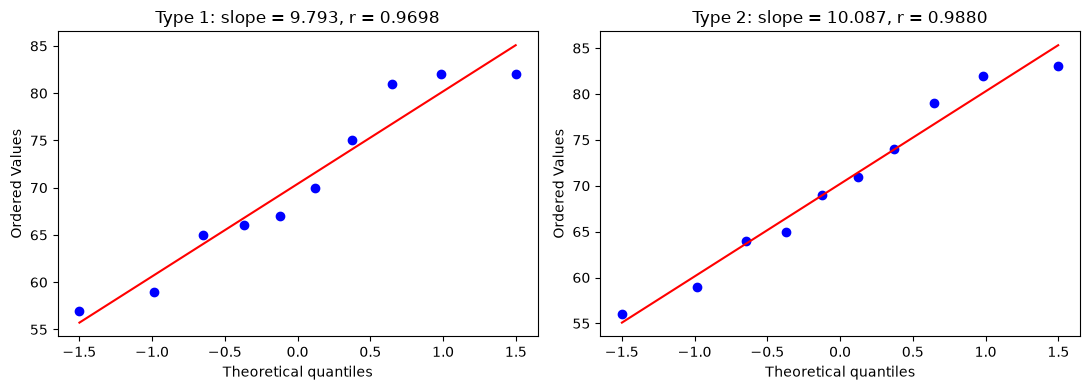

Shapiro-Wilk Type 1: statistic = 0.9136, p-value = 0.3065
Shapiro-Wilk Type 2: statistic = 0.9548, p-value = 0.7251


In [25]:
# 3) Check the assumption of normality for both types of flares
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y, name in zip(axes, [t1_26, t2_26], ["Type 1", "Type 2"]):
    (osm, osr), (slope, intercept, r) = stats.probplot(y, dist="norm", plot=ax)
    ax.set_title(f"{name}: slope = {slope:.3f}, r = {r:.4f}")
plt.tight_layout()
plt.show()

for y, name in zip([t1_26, t2_26], ["Type 1", "Type 2"]):
    stat_sw, p_sw = shapiro(y)
    print(f"Shapiro-Wilk {name}: statistic = {stat_sw:.4f}, p-value = {p_sw:.4f}")


**Role of the normality assumption.** Both the $F$-test and the pooled $t$-test assume that the
observations are normally distributed. The two tests are not equally sensitive to this: the $t$-test is
reasonably robust to moderate departures, because the central limit theorem acts on the sample means,
whereas the $F$-test for variances is notoriously sensitive — a departure from normality can make its
true significance level differ substantially from the nominal $\alpha = 0.05$. Conclusions about the
variances therefore rest on the assumption much more heavily than conclusions about the means.

The normal probability plots show points close to their fitted lines and the Shapiro-Wilk tests do not
reject normality ($p = 0.31$ for Type 1, $p = 0.73$ for Type 2), so the assumption is acceptable here.
With $n = 10$ per group these checks have little power, so this means the data are *consistent with*
normality rather than that normality has been established.


In [26]:
# 4) Power for a true difference of 2 minutes, and the sample size needed to detect 1 minute
analysis26 = TTestIndPower()

# Both differences below are given by the problem, not estimated from the data;
# only the pooled standard deviation comes from the sample.
delta_power26 = 2
effect_26 = delta_power26 / sp_26
power_26 = analysis26.power(effect_size=effect_26, nobs1=n1_26, alpha=alpha26, alternative="two-sided")
print(f"pooled sd = {sp_26:.4f}")
print(f"delta = {delta_power26} min -> effect size = {effect_26:.4f}")
print(f"power with n = {n1_26} per group: {power_26:.4f}")

delta_n26 = 1
effect_n26 = delta_n26 / sp_26
n_needed26 = analysis26.solve_power(effect_size=effect_n26, alpha=alpha26, power=0.9, alternative="two-sided")
print(f"\ndelta = {delta_n26} min -> effect size = {effect_n26:.4f}")
print(f"required sample size per group for power 0.9: {np.ceil(n_needed26):.0f}  (exact {n_needed26:.2f})")


pooled sd = 9.3155
delta = 2 min -> effect size = 0.2147
power with n = 10 per group: 0.0740

delta = 1 min -> effect size = 0.1073
required sample size per group for power 0.9: 1825  (exact 1824.58)


Both differences here are supplied by the problem ($\Delta = 2$ and $\Delta = 1$ minutes); the observed
difference of $0.2$ minutes is not used in the power calculation. Only $s_p = 9.32$ is estimated from the
sample.

The burning times are very variable relative to the differences of interest: a two-minute difference is
only $2/9.32 = 0.21$ standard deviations, so with ten flares per group the power is $0.074$ — such a
difference would almost always go undetected. Halving the target to one minute halves the effect size
again, and reaching power $0.9$ would require about $1825$ flares per group, which is not a practical
experiment. This is the honest reading of part 2): the test did not reject equality of means, but it was
far too insensitive for that to be evidence that the means are equal.


### Exercise 2.30

Front housings for cell phones are manufactured in an injection molding process. The time the part is allowed to cool in the mold before removal is thought to influence the occurrence of a particularly troublesome cosmetic defect, flow lines, in the finished housing. After manufacturing, the housings are inspected visually and assigned a score between 1 and 10 based on their appearance, with 10 corresponding to a perfect part and 1 corresponding to a completely defective part. An experiment was conducted using two cool-down times, 10 and 20 seconds, and 20 housings were evaluated at each level of cool-down time. All 40 observations in this experiment were run in random order.

Cool-down time 10 seconds:

| | | | |
|---|---|---|---|
| 1 | 3 | 2 | 6 |
| 1 | 5 | 3 | 3 |
| 5 | 2 | 1 | 1 |
| 5 | 6 | 2 | 8 |
| 3 | 2 | 5 | 3 |

Cool-down time 20 seconds:

| | | | |
|---|---|---|---|
| 7 | 6 | 8 | 9 |
| 5 | 5 | 9 | 7 |
| 5 | 4 | 8 | 6 |
| 6 | 8 | 4 | 5 |
| 6 | 8 | 7 | 7 |

* Is there evidence to support the claim that the longer cool-down time results in fewer appearance defects? Use $\alpha = 0.05$.
* What is the P-value for the test conducted in the previous part?
* Find a 95 percent confidence interval on the difference in means. Provide a practical interpretation of this interval.
* Compute the power of the test.

In [27]:
# Read the data from the URL
url_30 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_30.csv"
df30 = pd.read_csv(url_30, sep=";")

# Display the first few rows of the dataframe
df30.head()

,10 seconds,20 seconds
0,1,7
1,2,8
2,1,5
3,3,9
4,5,5


**Solution:**

In [28]:
# 1) Does the longer cool-down time give fewer appearance defects? alpha = 0.05
# A higher score means a better part, so "fewer defects at 20 s" means mu_20 > mu_10.
# One-sided test:  H0: mu_20 = mu_10  vs  H1: mu_20 > mu_10
y10 = df30["10 seconds"].to_numpy()
y20 = df30["20 seconds"].to_numpy()
n10, n20 = len(y10), len(y20)
alpha30 = 0.05

var10 = np.var(y10, ddof=1)
var20 = np.var(y20, ddof=1)

# Supporting F-test for equality of variances
F_30 = var10 / var20
p_F_30 = 2 * min(f.cdf(F_30, n10 - 1, n20 - 1), 1 - f.cdf(F_30, n10 - 1, n20 - 1))
print(f"mean(10 s) = {y10.mean():.4f}, mean(20 s) = {y20.mean():.4f}")
print(f"s^2(10 s) = {var10:.4f}, s^2(20 s) = {var20:.4f}")
print(f"F = {F_30:.4f} on ({n10-1}, {n20-1}) df, two-sided p-value = {p_F_30:.4f}")
print("Equal variances rejected" if p_F_30 < alpha30 else "No evidence against equal variances")

# Pooled one-sided t-test, upper tail
t_30, p_30 = stats.ttest_ind(y20, y10, equal_var=True, alternative="greater")
df_30 = n10 + n20 - 2
t_crit30 = t.ppf(1 - alpha30, df=df_30)
print(f"\nt-statistic: {t_30:.4f} on {df_30} df  (critical value {t_crit30:.4f})")
print("Reject H0" if p_30 < alpha30 else "Do not reject H0", f"at alpha = {alpha30}")


mean(10 s) = 3.3500, mean(20 s) = 6.5000
s^2(10 s) = 4.0289, s^2(20 s) = 2.3684
F = 1.7011 on (19, 19) df, two-sided p-value = 0.2559
No evidence against equal variances

t-statistic: 5.5696 on 38 df  (critical value 1.6860)
Reject H0 at alpha = 0.05


In [29]:
# 2) P-value for the test above
print(f"one-sided p-value: {p_30:.8f}  ({p_30:.2e})")


one-sided p-value: 0.00000111  (1.11e-06)


In [30]:
# 3) 95% confidence interval on the difference in means, mu_20 - mu_10
sp_30 = np.sqrt(((n10 - 1) * var10 + (n20 - 1) * var20) / df_30)
se_30 = sp_30 * np.sqrt(1 / n10 + 1 / n20)
diff_30 = y20.mean() - y10.mean()

ci_30 = t.interval(0.95, df=df_30, loc=diff_30, scale=se_30)
lower_30 = diff_30 - t_crit30 * se_30
print(f"difference of means = {diff_30:.4f}, pooled sd = {sp_30:.4f}, standard error = {se_30:.4f}")
print(f"95% CI for mu_20 - mu_10: ({ci_30[0]:.4f}, {ci_30[1]:.4f})")
print(f"95% lower confidence bound (matching the one-sided test): mu_20 - mu_10 > {lower_30:.4f}")


difference of means = 3.1500, pooled sd = 1.7885, standard error = 0.5656
95% CI for mu_20 - mu_10: (2.0051, 4.2949)
95% lower confidence bound (matching the one-sided test): mu_20 - mu_10 > 2.1965


**Practical interpretation.** With 95 % confidence the longer cool-down time improves the mean
appearance score by between $2.0$ and $4.3$ points on the ten-point scale. The interval lies entirely
above zero, which agrees with the rejection of $H_0$, and its lower end is far from zero: the improvement
is not only statistically detectable but large relative to the scale being used.


In [31]:
# 4) Power of the test
analysis30 = TTestIndPower()
effect_30 = diff_30 / sp_30
power_30 = analysis30.power(effect_size=effect_30, nobs1=n10, alpha=alpha30, alternative="larger")
print(f"effect size (Cohen's d) = {effect_30:.4f}")
print(f"power of the one-sided test with n = {n10} per group: {power_30:.6f}")


effect size (Cohen's d) = 1.7613
power of the one-sided test with n = 20 per group: 0.999934


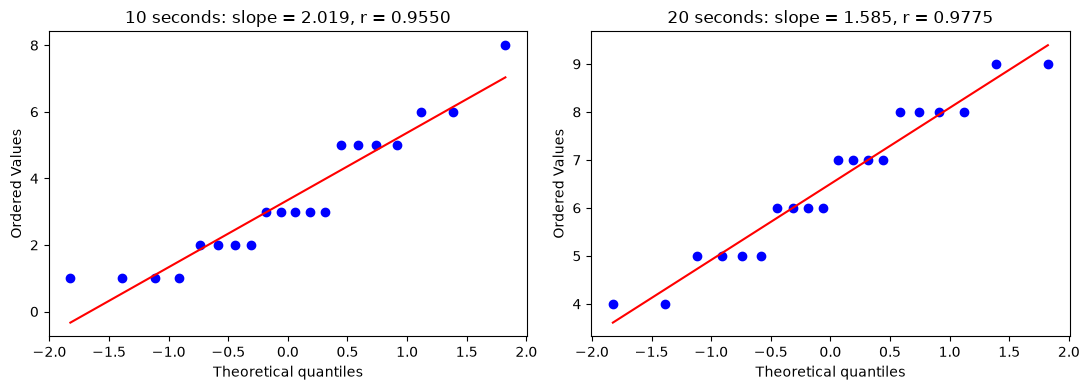

Shapiro-Wilk 10 seconds: statistic = 0.9034, p-value = 0.0479
Shapiro-Wilk 20 seconds: statistic = 0.9398, p-value = 0.2379

Mann-Whitney U test: U = 352.0, one-sided p-value = 1.77e-05


In [32]:
# Assumption check: the scores are discrete ratings from 1 to 10, so normality is worth inspecting
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y, name in zip(axes, [y10, y20], ["10 seconds", "20 seconds"]):
    (osm, osr), (slope, intercept, r) = stats.probplot(y, dist="norm", plot=ax)
    ax.set_title(f"{name}: slope = {slope:.3f}, r = {r:.4f}")
plt.tight_layout()
plt.show()

for y, name in zip([y10, y20], ["10 seconds", "20 seconds"]):
    stat_sw, p_sw = shapiro(y)
    print(f"Shapiro-Wilk {name}: statistic = {stat_sw:.4f}, p-value = {p_sw:.4f}")

# Distribution-free check of the same one-sided claim
u_30, p_u30 = stats.mannwhitneyu(y20, y10, alternative="greater")
print(f"\nMann-Whitney U test: U = {u_30:.1f}, one-sided p-value = {p_u30:.2e}")


**On the assumptions.** The responses are discrete appearance scores on a $1$--$10$ scale rather than
continuous measurements, so exact normality cannot hold. The Shapiro-Wilk test is borderline for the
10-second group ($p = 0.048$, marginally below $0.05$) and comfortable for the 20-second group
($p = 0.238$); the 10-second scores are bunched at the low end of the scale and mildly right-skewed.

With $n = 20$ per group the $t$-test is robust to a departure of this size, and the distribution-free
Mann-Whitney test gives the same conclusion with $p = 1.8 \times 10^{-5}$. The finding that the longer
cool-down time reduces defects therefore does not depend on the normality assumption.
